In [1]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix
from tqdm import tqdm
import os
import time
from sklearn.linear_model import LinearRegression

In [7]:
start_time = time.time()
groundtruth_df = pd.read_csv('/media/ssd1/huong/PCR-huong/data/groundtruth_df.csv')

curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))

join_df['test_kit'] = join_df.groupby('sample_id').curve_idx.transform(lambda x: x.nunique())
join_df['test_kit'] = np.where(join_df.test_kit == 3, 'Thermo', 'LuNER')
print('Total running time:', time.time() - start_time)

Total running time: 12.752052068710327


In [8]:
new_join_df = pd.read_pickle('/media/ssd1/huong/PCR-huong/data/new_join_df.pkl')

In [9]:
model_output_dir = '/media/ssd1/huong/PCR-huong/data/model_outputs/'
retest_pred = pd.read_csv(os.path.join(model_output_dir, 'experimental', 'seq_gene_retest_pred_df.csv'))
full_retest_pred = (retest_pred
                  .merge(join_df,#[['curve_idx','threshold','target','pcr_plate','test_kit','thres_ct','cycle_no','drn','igi_call','retest_sample_id_1','sample_barcode']],
                         on = ['curve_idx']))
              #     .merge(new_join_df[['well_position','pcr_plate','target','retest_sample_id_1']]))


In [14]:
retest_sample_id_1 = full_retest_pred.retest_sample_id_1.unique()

retest_sample_df = join_df[join_df.sample_barcode.isin(retest_sample_id_1)]

In [15]:
print('Number of samples that have retest_sample_id_1:', full_retest_pred.sample_barcode.nunique())
print('Number of found retested samples:', retest_sample_df.sample_id.nunique())
print('Number of curves in retested samples:', retest_sample_df.shape[0])

Number of samples that have retest_sample_id_1: 1236
Number of found retested samples: 813
Number of curves in retested samples: 123845


In [16]:
(retest_sample_df[retest_sample_df.cycle_no == 1]
 .merge(groundtruth_df, on ='curve_idx')
 .groupby('split')
 .curve_idx.nunique())

split
test      4
train    12
val       1
Name: curve_idx, dtype: int64

In [18]:
retest_sample_df['groundtruth_target'] = 0.
retest_sample_df.loc[retest_sample_df.target.isin(['RnaseP','MS2']), 'groundtruth_target'] = 1.0
retest_sample_df.loc[(~retest_sample_df.target.isin(['RnaseP','MS2'])) & (retest_sample_df.final_patient_result == 'Positive'), 'groundtruth_target'] = 1.


retest_sample_df['Igi_call_quant'] = 1*(retest_sample_df.igi_call == 'Positive')
retest_sample_df['igi_fp'] = (retest_sample_df['Igi_call_quant'] > retest_sample_df['groundtruth_target']).astype(int)
retest_sample_df['igi_fn'] = (retest_sample_df['Igi_call_quant'] < retest_sample_df['groundtruth_target']).astype(int)
retest_sample_df['split'] = 'test'


retest_sample_curve_dict = {}
for i in retest_sample_df.curve_idx.unique():
    df = retest_sample_df[retest_sample_df.curve_idx == i]
    retest_sample_curve_dict[i] = df['Fn'].to_list()

retest_sample_df = retest_sample_df[retest_sample_df.cycle_no == 40]

/tmp/ipykernel_1002943/3182027066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retest_sample_df['groundtruth_target'] = 0.
/tmp/ipykernel_1002943/3182027066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retest_sample_df['Igi_call_quant'] = 1*(retest_sample_df.igi_call == 'Positive')
/tmp/ipykernel_1002943/3182027066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [19]:
# retest_sample_df.to_csv('/media/ssd1/huong/PCR-huong/data/retested_sample_df_target_data.csv',index=False)

In [20]:
# import pickle
# with open('/media/ssd1/huong/PCR-huong/data/retested_sample_df_curve_dict.pkl','wb') as handle:
#     pickle.dump(retest_sample_curve_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [56]:
# for idx in  tqdm(range(len(retest_sample_curve_dict.keys()))):
#     curve_idx = list(retest_sample_curve_dict.keys())[idx]
#     sequence = retest_sample_curve_dict[curve_idx][:40]

#     if not os.path.exists('/media/ssd1/huong/PCR-huong/data/curve_imgs_no_axis/'):
#         os.makedirs('/media/ssd1/huong/PCR-huong/data/curve_imgs_no_axis/')
#     plt.plot(sequence, linewidth=6)
#     #plt.axis('off')  # This will turn off the axis labels and ticks
#     plt.axis('off') 
#     plt.show()
#     plt.savefig(f'/media/ssd1/huong/PCR-huong/data/curve_imgs_no_axis/curve_{curve_idx}.png')
#     plt.clf()



In [17]:
retested_sample_pred_df = pd.read_csv('/media/ssd1/huong/PCR-huong/data/model_outputs/experimental/seq_gene_retested_sample_pred_df.csv')
print(retested_sample_pred_df.shape)
full_retested_sample_pred_df = (retested_sample_pred_df
                                .merge(join_df.loc[join_df.cycle_no == 1, ['curve_idx','sample_barcode','sample_id','retest_sample_id_1','final_patient_result','target']],
                                       on='curve_idx')
                                )

print(full_retested_sample_pred_df.shape)

(543, 3)
(543, 8)


In [15]:
full_retested_sample_pred_df = (full_retested_sample_pred_df
                                .merge(full_retest_pred.loc[full_retest_pred.cycle_no == 1, ['retest_sample_id_1','target','outputs']],
                                       left_on=['sample_barcode','target'], right_on=['retest_sample_id_1','target'],
                                       suffixes=('_retested','_orig')))

In [16]:
full_retested_sample_pred_df.groupby('final_patient_result').sample_id.nunique()

final_patient_result
Negative    105
Positive     14
ReSample     19
Name: sample_id, dtype: int64

Text(0, 0.5, 'Retested sample predicted scores')

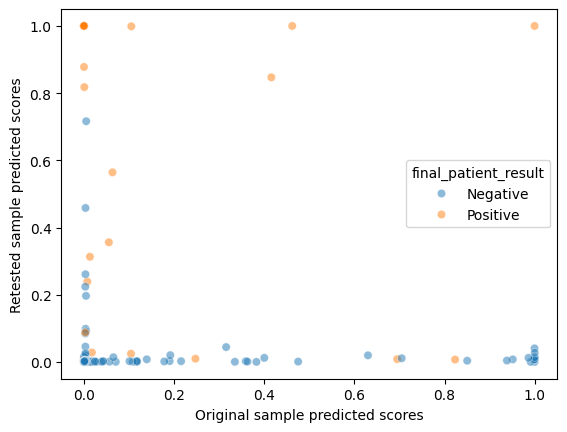

In [17]:

# plt.plot(full_retested_sample_pred_df[~full_retested_sample_pred_df.target.isin(['RnaseP','MS2'])].outputs_retested, 
#          full_retested_sample_pred_df[~full_retested_sample_pred_df.target.isin(['RnaseP','MS2'])].outputs_orig,'.',)

sns.scatterplot(full_retested_sample_pred_df[(~full_retested_sample_pred_df.target.isin(['RnaseP','MS2'])) & (full_retested_sample_pred_df.final_patient_result != 'ReSample')], 
                x='outputs_orig', y='outputs_retested', hue='final_patient_result', alpha=0.5)
plt.xlabel('Original sample predicted scores')
plt.ylabel('Retested sample predicted scores')

Correlation scores: [[ 1.         -0.00692882]
 [-0.00692882  1.        ]]


Text(0, 0.5, 'Retested sample predicted scores')

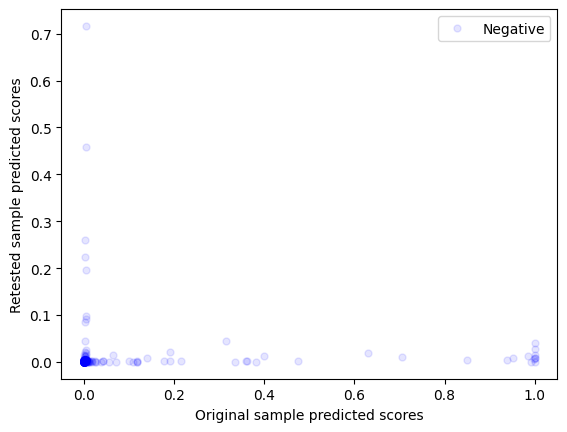

In [18]:
df = full_retested_sample_pred_df[(~full_retested_sample_pred_df.target.isin(['RnaseP','MS2'])) & 
                                  (full_retested_sample_pred_df.final_patient_result == 'Negative')]
print('Correlation scores:', np.corrcoef(df.outputs_orig, df.outputs_retested))
plt.plot(df.outputs_orig, df.outputs_retested, '.',color='blue', alpha=0.1, markersize=10, label='Negative')
plt.legend()
plt.xlabel('Original sample predicted scores')
plt.ylabel('Retested sample predicted scores')

Correlation scores: [[1.         0.00812196]
 [0.00812196 1.        ]]


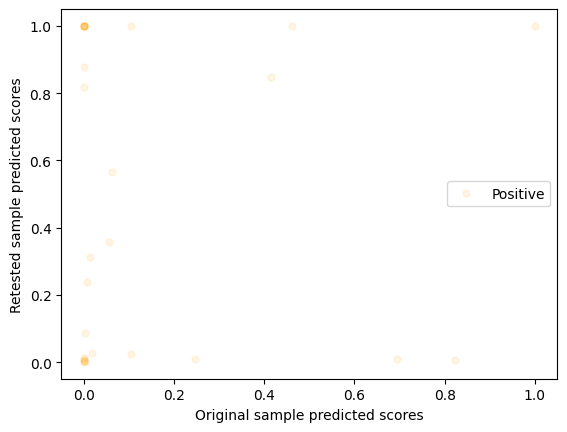

In [19]:
df = full_retested_sample_pred_df[(~full_retested_sample_pred_df.target.isin(['RnaseP','MS2'])) & 
                                  (full_retested_sample_pred_df.final_patient_result == 'Positive')]
print('Correlation scores:', np.corrcoef(df.outputs_orig, df.outputs_retested))
plt.plot(df.outputs_orig, df.outputs_retested, '.',color='orange', alpha=0.1, markersize=10, label='Positive')
plt.xlabel('Original sample predicted scores')
plt.ylabel('Retested sample predicted scores')
plt.legend()

In [21]:
retested_orig_auc = roc_auc_score(full_retested_sample_pred_df.groundtruth_label, full_retested_sample_pred_df.outputs_orig)
retested_retested_auc = roc_auc_score(full_retested_sample_pred_df.groundtruth_label, full_retested_sample_pred_df.outputs_retested)
print('AUC of predicting groundtruth from original samples:', retested_orig_auc)
print('AUC of predicting groundtruth from retested samples:', retested_retested_auc)

AUC of predicting groundtruth from original samples: 0.9141594246329038
AUC of predicting groundtruth from retested samples: 0.9841923883727899


In [22]:
best_acc_threshold = 0.5657657657657658

full_retested_sample_pred_df['orig_pred'] = 1*(full_retested_sample_pred_df.outputs_orig >= best_acc_threshold)
full_retested_sample_pred_df['retested_pred'] = 1*(full_retested_sample_pred_df.outputs_retested >= best_acc_threshold)

predict_retested_from_orig_auc = roc_auc_score(full_retested_sample_pred_df.retested_pred, 
                                                                        full_retested_sample_pred_df.outputs_orig)
print('If using original samples to predict retested samples, AUC is:', predict_retested_from_orig_auc)

If using original samples to predict retested samples, AUC is: 0.9314285714285714


Text(0, 0.5, 'Prediction from original samples')

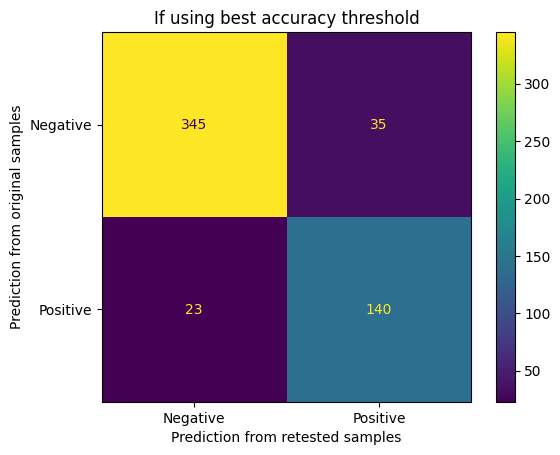

In [23]:


cm = confusion_matrix(full_retested_sample_pred_df.orig_pred, full_retested_sample_pred_df.retested_pred, labels=np.array([0,1]))
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot()
plt.title('If using best accuracy threshold')
plt.xlabel('Prediction from retested samples')
plt.ylabel('Prediction from original samples')


Text(0, 0.5, 'Groundtruth')

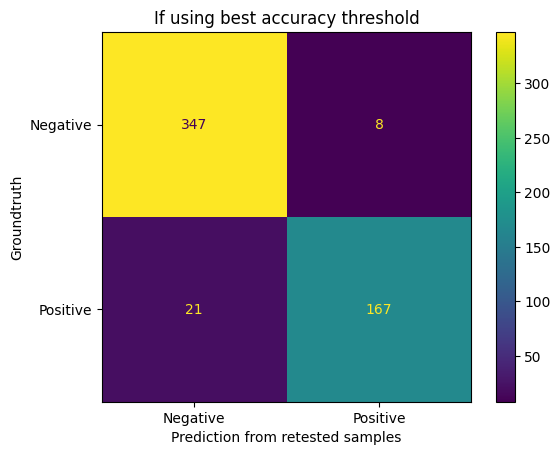

In [24]:
cm = confusion_matrix(full_retested_sample_pred_df.groundtruth_label, full_retested_sample_pred_df.retested_pred, labels=np.array([0,1]))
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot()
plt.title('If using best accuracy threshold')
plt.xlabel('Prediction from retested samples')
plt.ylabel('Groundtruth')

Text(0, 0.5, 'Groundtruth')

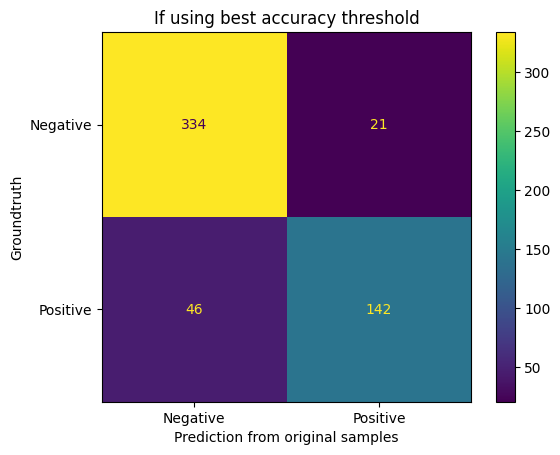

In [25]:
cm = confusion_matrix(full_retested_sample_pred_df.groundtruth_label, full_retested_sample_pred_df.orig_pred, labels=np.array([0,1]))
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot()
plt.title('If using best accuracy threshold')
plt.xlabel('Prediction from original samples')
plt.ylabel('Groundtruth')

In [26]:
full_retested_sample_pred_df['orig_bin'] = pd.cut(full_retested_sample_pred_df.outputs_orig, 10, labels= list(range(10)))


/tmp/ipykernel_770324/2716306464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = (full_retested_sample_pred_df.groupby('orig_bin').outputs_retested.mean().reset_index())


Text(0, 0.5, 'Retested sample average predicted score')

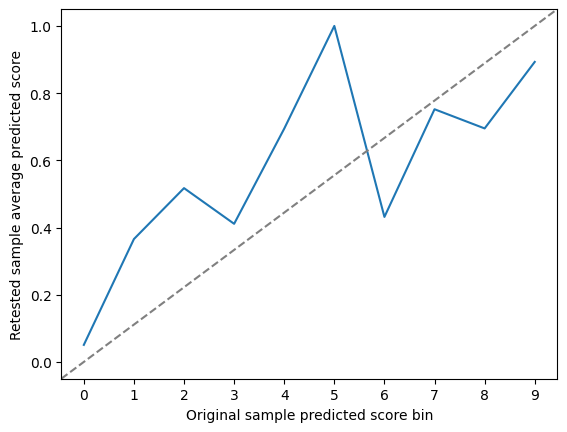

In [27]:
df = (full_retested_sample_pred_df.groupby('orig_bin').outputs_retested.mean().reset_index())
plt.plot(df.orig_bin, df.outputs_retested)
plt.axline((0,0), (9,1), linestyle='--', color='gray')
plt.xticks(range(10))
plt.xlabel('Original sample predicted score bin')
plt.ylabel('Retested sample average predicted score')

R-squared: 0.6612113391227716


Text(0.5, 1.0, 'Best fitted line for $P_{retested\\ samples}$ ~ $P_{original\\ samples}$')

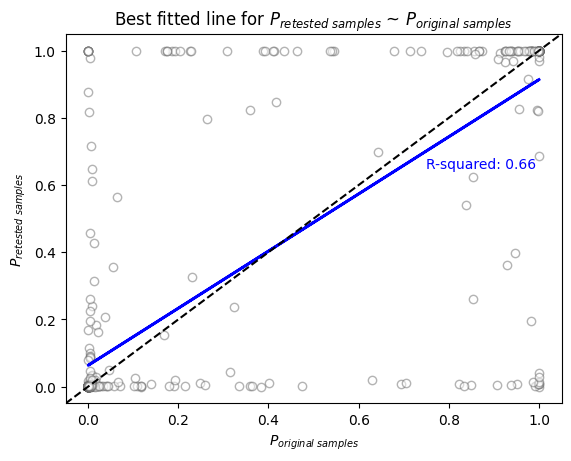

In [58]:
lm_model = LinearRegression().fit(full_retested_sample_pred_df[['outputs_orig']],
                                   full_retested_sample_pred_df[['outputs_retested']])
print('R-squared:', lm_model.score(full_retested_sample_pred_df[['outputs_orig']],
                                   full_retested_sample_pred_df[['outputs_retested']]))
outputs_retested_lm_pred = lm_model.predict(full_retested_sample_pred_df[['outputs_orig']])
plt.scatter(full_retested_sample_pred_df.outputs_orig, full_retested_sample_pred_df.outputs_retested, 
            color='white', edgecolors='dimgrey', alpha=0.5)
plt.plot(full_retested_sample_pred_df.outputs_orig, outputs_retested_lm_pred, color='blue', linewidth=2)
plt.axline((0,0),(1,1), color='black', linestyle='--')
plt.text(x=0.75, y=0.65, s='R-squared: 0.66', color='blue')
plt.xlabel('$P_{original\ samples}$')
plt.ylabel('$P_{retested\ samples}$')
plt.title('Best fitted line for $P_{retested\ samples}$ ~ $P_{original\ samples}$')